# Lab 7 - Przepływ optyczny

### Metoda Blokowa

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

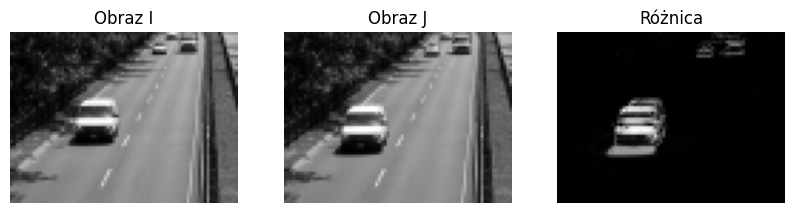

In [34]:
I_color = cv2.imread('I.jpg')
J_color = cv2.imread('J.jpg')

I_gray = cv2.cvtColor(I_color, cv2.COLOR_BGR2GRAY)
J_gray = cv2.cvtColor(J_color, cv2.COLOR_BGR2GRAY)

# Zmniejszenie dla przyspieszenia obliczeń
I = cv2.resize(I_gray, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
J = cv2.resize(J_gray, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)

plt.figure(figsize=(10, 6))
plt.subplot(1, 3, 1)
plt.imshow(I, cmap='gray')
plt.title('Obraz I')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(J, cmap='gray')
plt.title('Obraz J')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.absdiff(I, J), cmap='gray')
plt.title('Różnica')
plt.axis('off')
plt.show()

In [39]:
def block_method(I, J, win_size=7):
	w2 = win_size // 2
	dx = 3
	dy = 3
	Y, X = I.shape

	u = np.zeros((Y, X), dtype=np.float32) # Macierz na przesunięcia w osi X
	v = np.zeros((Y, X), dtype=np.float32) # Macierz na przesunięcia w osi Y

	for j in range(w2, Y - w2):
		for i in range(w2, X - w2):
			IO = np.float32(I[j-w2 : j+w2+1, i-w2 : i+w2+1])
			JO_center = np.float32(J[j-w2 : j+w2+1, i-w2 : i+w2+1])
			min_dist = np.sqrt(np.sum(np.square(JO_center - IO)))
			best_match = (0, 0)

			for y in range(-dy, dy+1):
				for x in range(-dx, dx+1):
					if x == 0 and y == 0:
						continue

					# Sprawdzenie czy współrzędne mieszczą się w zakresie
					if (j + y - w2 >= 0 and j + y + w2 + 1 <= Y and
						i + x - w2 >= 0 and i + x + w2 + 1 <= X):
						JO = np.float32(J[j+y-w2 : j+y+w2+1, i+x-w2 : i+x+w2+1])

						dist = np.sqrt(np.sum(np.square(JO - IO)))
						if dist < min_dist:
							min_dist = dist
							best_match = (x, y)

			u[j, i] = best_match[0]
			v[j, i] = best_match[1]
	
	# Wizualizacja
	mag, ang = cv2.cartToPolar(u, v)
	hsv = np.zeros((Y, X, 3), dtype=np.uint8)
	hsv[..., 0] = ang * 90 / np.pi # Kąt w stopniach (0-180)
	hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX) # Kanał V to normalizowana wartość przesunięcia
	hsv[..., 1] = 255 # Kanał S ma maksymalną wartość

	rgb_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

	plt.figure(figsize=(18, 6))
	plt.subplot(1, 3, 1), plt.imshow(I, cmap='gray'), plt.title('Obraz I'), plt.axis('off')
	plt.subplot(1, 3, 2), plt.imshow(J, cmap='gray'), plt.title('Obraz J'), plt.axis('off')
	plt.subplot(1, 3, 3), plt.imshow(rgb_flow), plt.title('Pole Przesunięć'), plt.axis('off')
	plt.show()	

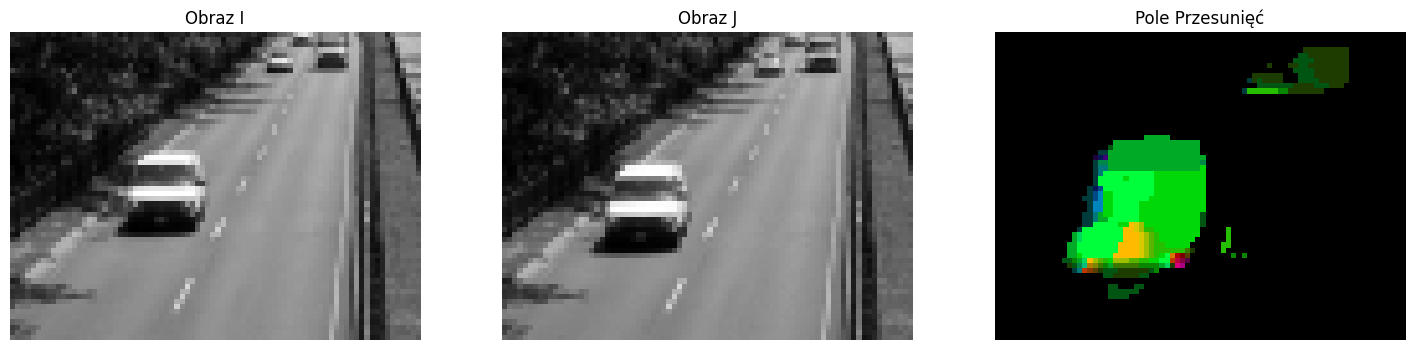

In [40]:
block_method(I, J)

### Wieloskalowa metoda blokowa

In [15]:
def of(I, J, W2=3, dy=3, dx=3):
	H, W = I.shape

	u = np.zeros((H, W), dtype=np.float32)
	v = np.zeros((H, W), dtype=np.float32)

	for j in range(W2, H - W2):
		for i in range(W2, W - W2):
			I0 = np.float32(I[j-W2 : j+W2+1, i-W2 : i+W2+1])

			J0_center = np.float32(J[j-W2 : j+W2+1, i-W2 : i+W2+1])
			min_dist = np.sqrt(np.sum(np.square(J0_center - I0)))
			best_match = (0, 0)

			for y in range(-dy, dy+1):
				for x in range(-dx, dx+1):
					if x == 0 and y == 0:
						continue

					if (j + y - W2 >= 0 and j + y + W2 + 1 <= H and 
						i + x - W2 >= 0 and i + x + W2 + 1 <= W):
						
						J0 = np.float32(J[j+y-W2 : j+y+W2+1, i+x-W2 : i+x+W2+1])
						dist = np.sqrt(np.sum(np.square(J0 - I0)))
						
						if dist < min_dist:
							min_dist = dist
							best_match = (x, y) 
			u[j, i] = best_match[0]
			v[j, i] = best_match[1]
	return u, v

In [16]:
def vis_flow(u, v, name="Przepływ optyczny"):
    H, W = u.shape
    mag, ang = cv2.cartToPolar(u, v)
    hsv = np.zeros((H, W, 3), dtype=np.uint8)
    hsv[..., 0] = ang * 90 / np.pi 
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX) 
    hsv[..., 1] = 255 
    rgb_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb_flow)
    plt.title(name)
    plt.axis('off')
    plt.show()

In [17]:
# Funkcja do tworzenia piramidy obrazów
def pyramid(im, max_scale):
    images = [im]
    for k in range(1, max_scale):
        # Dwukrotne zmniejszenie obrazu
        images.append(cv2.resize(images[k-1], (0, 0), fx=0.5, fy=0.5))
    return images

In [18]:
def warp_image(J, u, v):
    H, W = J.shape
    X, Y = np.meshgrid(np.arange(W), np.arange(H))
    
    map_x = np.float32(X + u)
    map_y = np.float32(Y + v)
    
    J_warped = cv2.remap(J, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    return J_warped

Obliczanie skali 2...
Obliczanie skali 1...
Obliczanie skali 0...


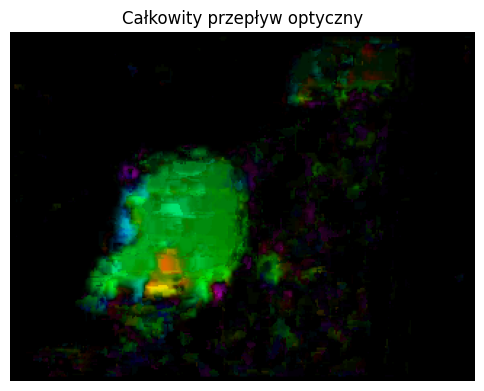

In [ ]:
MAX_SCALE = 3
pyr_I = pyramid(I, MAX_SCALE)
pyr_J = pyramid(J, MAX_SCALE)

u_total = None
v_total = None

for s in range(MAX_SCALE-1, -1, -1):
	I_scale = pyr_I[s]
	J_scale = pyr_J[s]
	
	H, W = I_scale.shape
	if u_total is not None and v_total is not None:
		u_total = np.float32(cv2.resize(u_total, (W, H), interpolation=cv2.INTER_LINEAR) * 2.0)
		v_total = np.float32(cv2.resize(v_total, (W, H), interpolation=cv2.INTER_LINEAR) * 2.0)

		J_warped = warp_image(J_scale, u_total, v_total)
	else:
		u_total = np.zeros((H, W), dtype=np.float32)
		v_total = np.zeros((H, W), dtype=np.float32)
		J_warped = J_scale.copy()
	
	print(f"Obliczanie skali {s}...")

	du, dv = of(I_scale, J_warped, W2=3, dy=3, dx=3)

	u_total += du
	v_total += dv

vis_flow(u_total, v_total, name="Całkowity przepływ optyczny")

### Inne sposoby wyznaczenia przepływu optycznego

#### Gęsty przepływ optyczny (Farneback)

In [10]:
# import os
# import glob

# def process_sequence(path):
# 	input_path = os.path.join("../lab02", path, "input", "*.jpg")

# 	input_files = sorted(glob.glob(input_path))
# 	if not input_files:
# 		print("Nie znaleziono plików w katalogu:", input_path)
# 		return

# 	roi_file = os.path.join("../lab02", path, "temporalROI.txt")
# 	if os.path.exists(roi_file):
# 		with open(roi_file, 'r') as f:
# 			start_frame, end_frame = map(int, f.read().split())
# 	else:
# 		start_frame, end_frame = 1, len(input_files)
# 	print(f"Przetwarzanie sekwencji {path} od klatki {start_frame} do {end_frame}...")

# 	prev_frame = cv2.imread(input_files[start_frame -1], cv2.IMREAD_GRAYSCALE)
# 	if prev_frame is None:
# 		return

# 	H, W = prev_frame.shape
# 	hsv = np.zeros((H, W, 3), dtype=np.uint8)
# 	hsv[..., 1] = 255


# 	for i in range(start_frame, end_frame):
# 		curr_frame = cv2.imread(input_files[i], cv2.IMREAD_GRAYSCALE)
# 		if curr_frame is None:
# 			continue

# 		flow = cv2.calcOpticalFlowFarneback(prev_frame, curr_frame, None, 0.5, 3, 15, 3, 5, 1.2, 0)
# 		mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

# 		mag[mag > 10] = 10 # Ograniczenie modułu do 10

# 		hsv[..., 0] = ang * 90 / np.pi
# 		hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

# 		bgr_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# 		cv2.imshow("Obraz oryginalny", curr_frame)
# 		cv2.imshow("Przeplyw Gesty (Farneback)", bgr_flow)

# 		if cv2.waitKey(10) & 0xFF == 27:
# 			break
		
# 		prev_frame = curr_frame.copy()
# 	cv2.destroyAllWindows()

In [11]:
# process_sequence("highway")

#### Przepływ Rzadki (Lucas-Kanade)

In [12]:

# def process_sequence_sparse(path):
# 	input_path = os.path.join("../lab02", path, "input", "*.jpg")

# 	input_files = sorted(glob.glob(input_path))
# 	if not input_files:
# 		print("Nie znaleziono plików w katalogu:", input_path)
# 		return

# 	roi_file = os.path.join("../lab02", path, "temporalROI.txt")
# 	if os.path.exists(roi_file):
# 		with open(roi_file, 'r') as f:
# 			start_frame, end_frame = map(int, f.read().split())
# 	else:
# 		start_frame, end_frame = 1, len(input_files)
# 	print(f"Przetwarzanie sekwencji {path} od klatki {start_frame} do {end_frame}...")

# 	prev_frame = cv2.imread(input_files[start_frame -1], cv2.IMREAD_GRAYSCALE)
# 	if prev_frame is None:
# 		return

# 	H, W = prev_frame.shape
# 	step = 10
	
# 	y_coords, x_coords = np.mgrid[step//2:H:step, step//2:W:step]
# 	points = np.float32(np.column_stack((x_coords.ravel(), y_coords.ravel()))).reshape(-1, 1, 2)


# 	lk_params = dict(winSize=(15,15), maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))



# 	for i in range(start_frame, end_frame):
# 		curr_frame = cv2.imread(input_files[i], cv2.IMREAD_GRAYSCALE)
# 		curr_frame_color = cv2.imread(input_files[i])

# 		if curr_frame is None or curr_frame_color is None:
# 			continue

# 		new_points, st, err = cv2.calcOpticalFlowPyrLK(prev_frame, curr_frame, points, None, **lk_params)

# 		for jj in range(len(points)):
# 			if st[jj] == 1:
# 				x1, y1 = points[jj, 0].astype(int)
# 				x2, y2 = new_points[jj, 0].astype(int)

# 				magnitude = np.sqrt((x2 - x1)**2 + (y2-y1)**2)
# 				if magnitude > 1.0:
# 					cv2.line(curr_frame_color, (x1, y1), (x2, y2), (0,0,255), 1)
# 					cv2.circle(curr_frame_color, (x2, y2), 2, (0,255,0), -1)

# 		cv2.imshow("Przeplyw Rzadkki", curr_frame_color)
# 		if cv2.waitKey(10) & 0xFF == 27:
# 			break

# 		prev_frame = curr_frame.copy()
# 	cv2.destroyAllWindows()

In [13]:
# process_sequence_sparse("highway")

### Dla I i J nie dla sekwencji

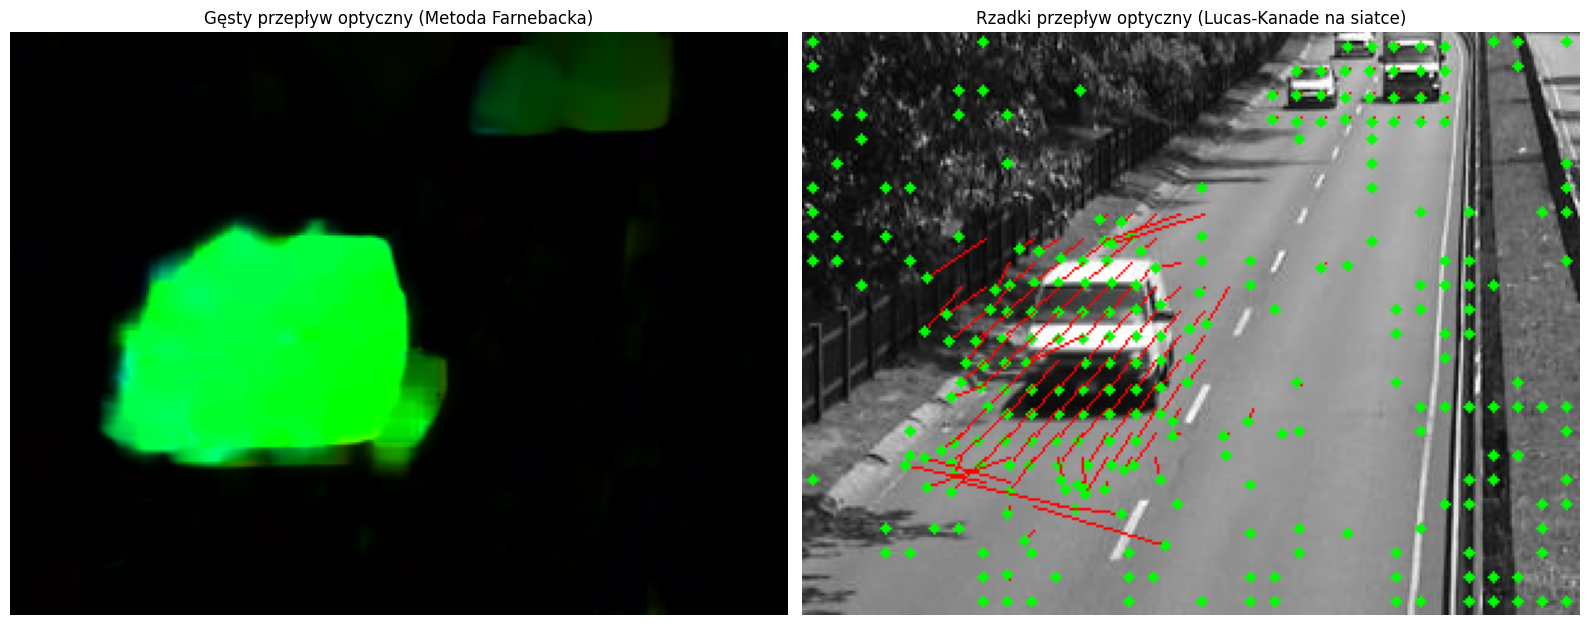

In [14]:
I_color = cv2.imread('I.jpg')
J_color = cv2.imread('J.jpg')

if I_color is None or J_color is None:
    print("Błąd wczytywania obrazów! Sprawdź czy ścieżki do plików są poprawne.")
else:
    I = cv2.cvtColor(I_color, cv2.COLOR_BGR2GRAY)
    J = cv2.cvtColor(J_color, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(I, J, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    u = flow[..., 0]
    v = flow[..., 1]

    mag, ang = cv2.cartToPolar(u, v)
    mag[mag > 10] = 10 

    H, W = I.shape
    hsv = np.zeros((H, W, 3), dtype=np.uint8)
    hsv[..., 0] = ang * 90 / np.pi
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    hsv[..., 1] = 255

    rgb_dense = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


    step = 10
    y_coords, x_coords = np.mgrid[step//2:H:step, step//2:W:step]
    points = np.float32(np.column_stack((x_coords.ravel(), y_coords.ravel()))).reshape(-1, 1, 2)

    lk_params = dict(winSize=(15, 15), maxLevel=2, 
                     criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    new_points, st, err = cv2.calcOpticalFlowPyrLK(I, J, points, None, **lk_params)

    sparse_vis = I_color.copy()

    for jj in range(len(points)):
        if st[jj] == 1:
            x1, y1 = points[jj, 0].astype(int)
            x2, y2 = new_points[jj, 0].astype(int)

			# Odrzucenie mikroruchów
            magnitude = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            if magnitude > 1.0:
                cv2.line(sparse_vis, (x1, y1), (x2, y2), (0, 0, 255), 1)  
                cv2.circle(sparse_vis, (x2, y2), 2, (0, 255, 0), -1)      

    rgb_sparse = cv2.cvtColor(sparse_vis, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 8))
    
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_dense)
    plt.title("Gęsty przepływ optyczny (Metoda Farnebacka)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(rgb_sparse)
    plt.title("Rzadki przepływ optyczny (Lucas-Kanade na siatce)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()